In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from plot_functions import plot_baseline_boxplots,plot_baseline_boxplots_metrics

# Define Path to results folder
results_path = Path("../Results")

In [15]:
def plot_baseline_boxplots(general_results_folder, subfolders=("Base", "Base_Energy")):
    """
    Plots boxplots for the metrics found in the CSV files of the specified subfolders.
    
    Input:
    - general_results_folder = Path to the main results directory
    - subfolders = Tuple or list of folder names to compare (e.g., "Base" vs "Base_Energy")
    - metrics = List of metrics (columns) to plot
    """
    general_results_folder = Path(general_results_folder)
    metrics = ["Food_Consumed", "Total_Reward", "Snake_Length", "Steps"]
        
    # Load the CSV data from the specified folders
    data_dict = {}
    for folder_name in subfolders:
        folder_path = general_results_folder / folder_name
        folder_path = Path(folder_path)
        if not folder_path.exists():
            print(f"Warning: Folder '{folder_path}' does not exist.")
            continue
            
        csv_files = list(folder_path.glob("*.csv"))
        if not csv_files:
            print(f"Warning: No CSV files found in '{folder_path}'.")
            continue
            
        # Read and concatenate all CSVs in this subfolder
        dfs = [pd.read_csv(f) for f in csv_files]

        # data_dict will hold the dataframes we have from the baseline runs in a dictionary 
        data_dict[folder_name] = pd.concat(dfs, ignore_index=True)
        
    if not data_dict:
        print("No data found to plot.")
        return
        
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_data = []
        labels = []
        
        for folder_name in subfolders:
            if folder_name in data_dict and metric in data_dict[folder_name].columns:
                # Extract the metric data and drop NaNs just in case
                metric_data = data_dict[folder_name][metric].dropna()
                plot_data.append(metric_data)
                labels.append(folder_name)
                
        if not plot_data:
            print(f"Warning: No data found for metric '{metric}'.")
            ax.set_visible(False)
            continue
            
        ax.boxplot(
            plot_data,
            labels=labels,
            showmeans=True,
            meanprops={
                "marker": "s",
                "markerfacecolor": "green",
                "markeredgecolor": "green",
            },
        )
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        # Compute means for each condition
        means = [d.mean() for d in plot_data]
        x = np.arange(1, len(means) + 1)
        ax.plot(x, means, linestyle='--', marker='o', color='red', linewidth=2, label='Mean trend', alpha=0.5)
        for x_pos, mean_value in zip(x, means):
            ax.annotate(
                f"{mean_value:.1f}",
                xy=(x_pos, mean_value),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=11,
                color="green",
            )
        
        ax.legend(fontsize=12)
        ax.set_title(f"{metric} Comparison: {' vs '.join(labels)}", fontsize=16)
        ax.set_ylabel(metric, fontsize=14)
        ax.grid(axis="y", alpha=0.3)
        
    plt.tight_layout()
    plt.show()

/var/folders/x0/b0lpwmms6zz206y0wr0qlzq00000gn/T/ipykernel_47997/2081237144.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/x0/b0lpwmms6zz206y0wr0qlzq00000gn/T/ipykernel_47997/2081237144.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/x0/b0lpwmms6zz206y0wr0qlzq00000gn/T/ipykernel_47997/2081237144.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/x0/b0lpwmms6zz206y0wr0qlzq00000gn/T/ipykernel_47997/2081237144.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

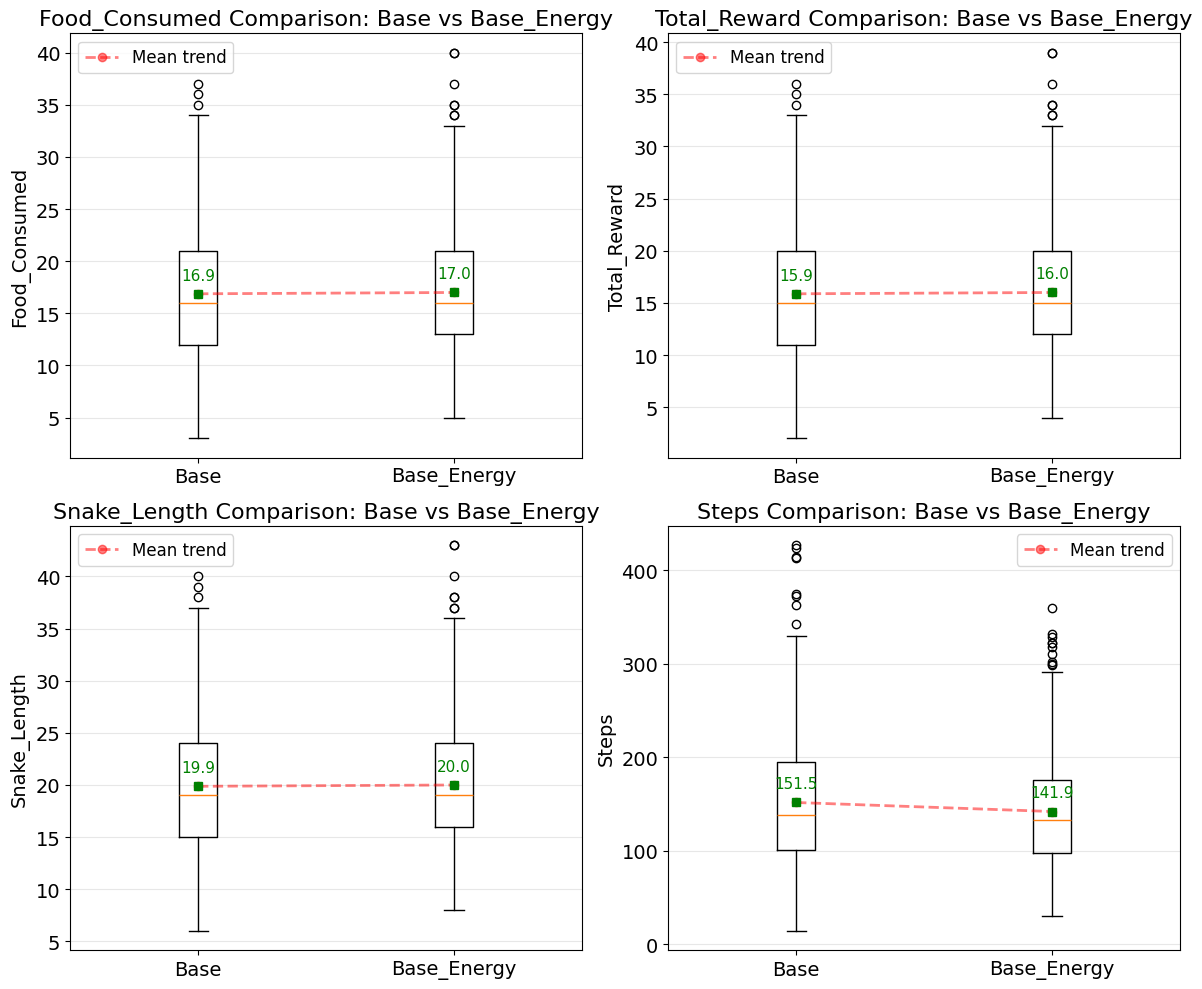

In [16]:
plot_baseline_boxplots(results_path, subfolders=("Base", "Base_Energy"))

# Interpretation of the plots
These are the plota from the baseline snake game. Baseline means that there are no drugs spawning during the gameplay and the snake can only eat food.



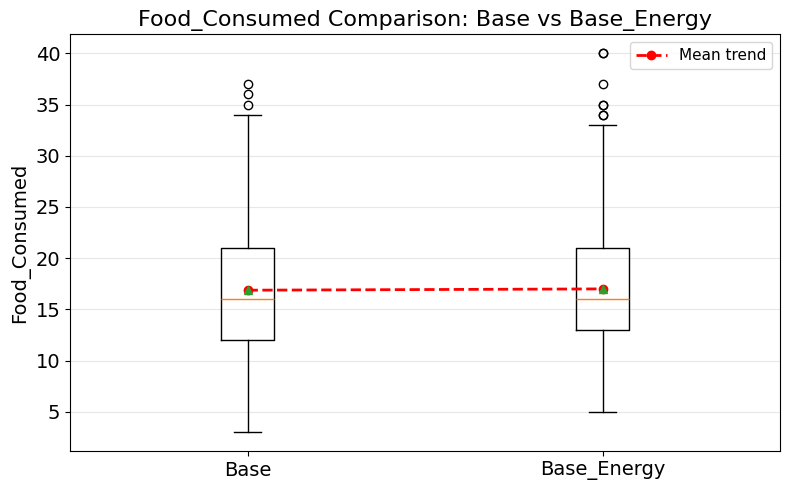

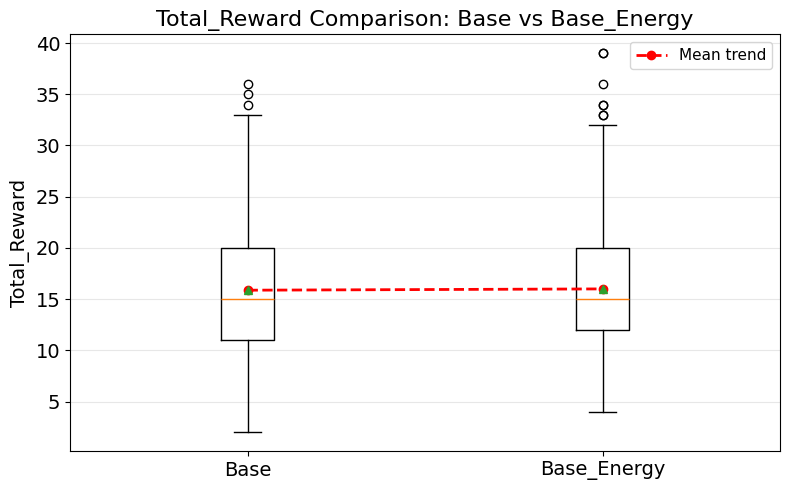

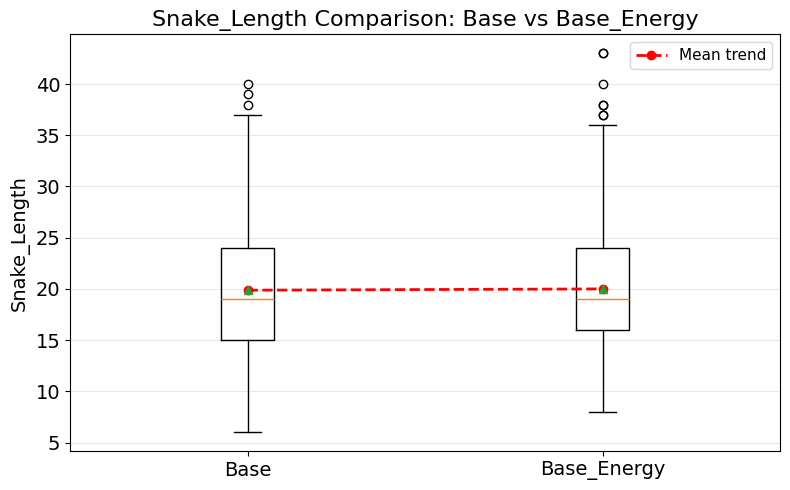

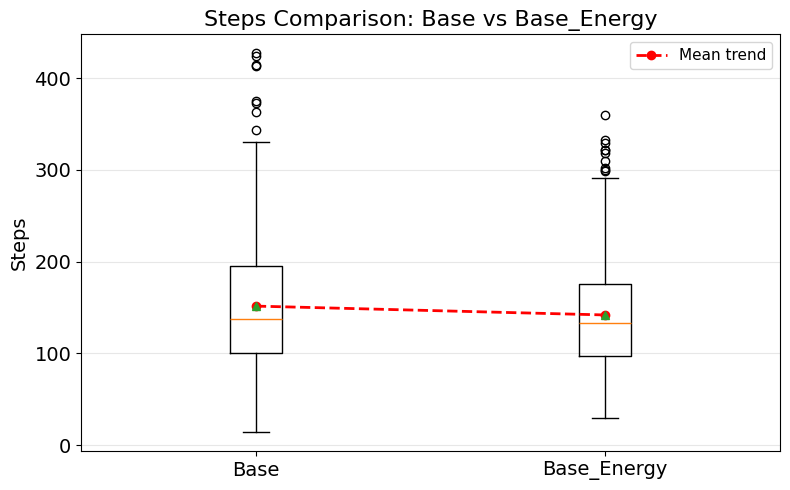

In [4]:
plot_baseline_boxplots_metrics(results_path, subfolders=("Base", "Base_Energy"))